# Mozambique House Price Prediction Using Linear Regression

## Project Overview

This notebook develops a machine-learning model to investigate whether property characteristics can be used to predict residential property prices in Mozambique.

The analysis uses the cleaned dataset produced during the data-cleaning stage.

A Linear Regression model is used as a baseline predictive model.

# Objective

The main objective is to develop a model that predicts property prices using selected characteristics of residential properties.

The predictor variables include property features such as:

- Number of bedrooms
- Number of bathrooms
- Number of parking spaces

The target variable is the property price.

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [5]:
df = pd.read_csv("ML_moz.csv")

In [6]:
df.head()

,Page,Title,Price,Location,Address,Description,Bedrooms,Bathrooms,Parking,Floor_Size_m2,URL,Region
0,1,4 Bedroom House,23975000,Bilene Central,"Rua De Marginal, Bilene Central, Bilene",A rare opportunity to own a fully serviced bea...,4.0,1.0,4.0,180 m²,https://www.property24.co.mz/4-bedroom-house-f...,South
1,1,4 Bedroom House,8000000,Bilene Central,"P8R2+52 Praia Do Bilene, Bilene Central, Bilene",Are you searching for your dream property for ...,4.0,3.0,4.0,225 m²,https://www.property24.co.mz/4-bedroom-house-f...,South
2,1,3 Bedroom House,5950000,Bilene Central,"P8X6+WR Praia Do Bilene, Bilene Central, Bilene",Move 2 Moz is incredibly proud to market this ...,3.0,3.0,1.0,145 m²,https://www.property24.co.mz/3-bedroom-house-f...,South
3,1,4 Bedroom House,26000000,Bilene Central,"123 Beach road, Bilene Central, Bilene",A rare opportunity to own a fully serviced bea...,4.0,3.0,4.0,220 m²,https://www.property24.co.mz/4-bedroom-house-f...,South
4,1,5 Bedroom House,7600000,Bilene Central,"Bilene, Bilene Central, Bilene",Discover this unique 5-bedroom beachside home ...,5.0,2.0,4.0,3 500 m²,https://www.property24.co.mz/5-bedroom-house-f...,South


## Define Features and Target Variable

The predictor variables are stored in `X`, while the property price is stored in `y`.

The model will attempt to learn the relationship between the selected property characteristics and the observed property prices.

## Train-Test Split

The dataset is divided into training and testing subsets.

The training data is used to fit the Linear Regression model, while the testing data is used to evaluate how well the model performs on previously unseen observations.

In [8]:
X = df[['Bedrooms', 'Bathrooms', 'Parking', ]]
y = df['Price']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Model Evaluation

The performance of the Linear Regression model is evaluated using standard regression metrics.

These include:

- **R² (R-squared)** – measures the proportion of variation in property prices explained by the model.
- **MAE (Mean Absolute Error)** – measures the average absolute difference between predicted and actual prices.
- **MSE (Mean Squared Error)** – measures the average squared prediction error.
- **RMSE (Root Mean Squared Error)** – provides an estimate of the typical prediction error in the same units as the target variable.

In [11]:
y_pred = model.predict(X_test)

In [12]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [13]:
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 6577503.048463602
R2 Score: 0.00929377191050762


In [14]:
def predict_price(bedrooms, bathrooms, parking,):
    input_data = pd.DataFrame([[bedrooms, bathrooms, parking, ]],
                              columns=X.columns)

    prediction = model.predict(input_data)[0]

    return f"Estimated Price: MT {prediction:,.0f}"

In [15]:
predict_price(3, 6, 1)

'Estimated Price: MT 14,929,908'

In [16]:
df['Predicted_Price'] = model.predict(X)

In [17]:
df['Difference'] = df['Price'] - df['Predicted_Price']

In [18]:
def classify(row):
    if row['Difference'] < -1000000:
        return 'OVERPRICED'
    elif row['Difference'] > 1000000:
        return 'UNDERPRICED'
    else:
        return 'FAIR'

df['Price_Status'] = df.apply(classify, axis=1)

In [47]:
print(df[['Price', 'Predicted_Price', 'Difference', 'Price_Status']].head(10))

      Price  Predicted_Price    Difference Price_Status
0  23975000     3.445840e+07 -1.048340e+07   OVERPRICED
1   8000000     1.453880e+07 -6.538803e+06   OVERPRICED
2   5950000     6.920910e+06 -9.709102e+05         FAIR
3  26000000     1.453880e+07  1.146120e+07  UNDERPRICED
4   7600000     1.189648e+07 -4.296481e+06   OVERPRICED
5   9750000     6.186442e+06  3.563558e+06  UNDERPRICED
6  10000000     1.971697e+07 -9.716969e+06   OVERPRICED
7   1850000     6.186442e+06 -4.336442e+06   OVERPRICED
8   6750000     1.453880e+07 -7.788803e+06   OVERPRICED
9  11000000     1.347710e+07 -2.477095e+06   OVERPRICED


In [19]:
import matplotlib.pyplot as plt


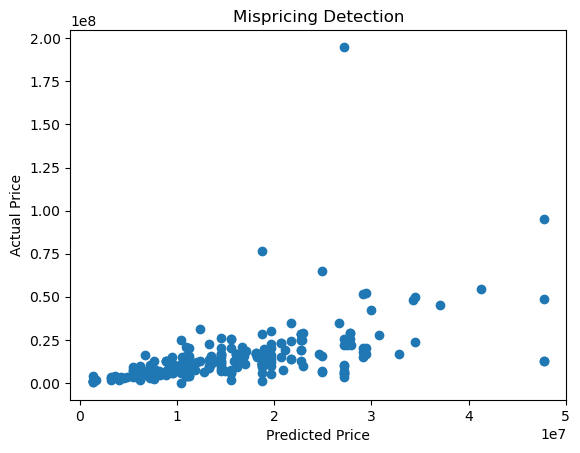

In [49]:
plt.scatter(df['Predicted_Price'], df['Price'])
plt.xlabel("Predicted Price")
plt.ylabel("Actual Price")
plt.title("Mispricing Detection")
plt.show()

## Actual vs Predicted Prices

The following visualization compares the actual property prices with the prices predicted by the Linear Regression model.

A model with stronger predictive performance would generally produce predictions that are closer to the actual values.

## Model Results

The initial Linear Regression model produced the following results:

- **Mean Absolute Error (MAE):** 6,577,503 MT
- **R² Score:** 0.0093

The R² score indicates that the model explains approximately **0.93% of the variation in property prices** in the test dataset.

The Mean Absolute Error (MAE) indicates that, on average, the model's predictions differ from the actual property prices by approximately **6.58 million MT**.

## Interpretation

The model has relatively weak predictive performance. This suggests that the selected variables, including bedrooms, bathrooms, parking spaces and regional variables, are not sufficient to accurately predict house prices in this dataset.

However, this result is useful for learning purposes. The project demonstrates the complete machine-learning workflow, from collecting real-world data and cleaning the data to training a model and evaluating its performance.

The low R² score also demonstrates an important lesson in machine learning: applying an algorithm does not automatically result in accurate predictions.

House prices may be influenced by many additional factors that are not included in the current model, such as:

- Property size
- Property type
- Exact location
- Land size
- Property condition
- Number of floors
- Amenities
- Distance from important services and infrastructure

## Lessons Learned

Although the initial model has weak predictive performance, it provides a useful baseline for future improvements.

Future versions of this project could:

- Collect a larger dataset
- Include additional property characteristics
- Improve location information
- Perform more extensive feature engineering
- Test different machine-learning algorithms
- Compare the performance of different models

The main purpose of this project is to learn and demonstrate the end-to-end machine-learning process using real-world property data from Mozambique.

# Conclusion

This project demonstrated an end-to-end data-science workflow using real-world property data from Mozambique.

The workflow consisted of:

1. Web scraping property listings using BeautifulSoup.
2. Creating a raw property dataset.
3. Cleaning and transforming the raw data.
4. Preparing the dataset for machine learning.
5. Developing a Linear Regression model.
6. Evaluating the model using regression performance metrics.

The project provides a baseline approach to Mozambique house-price prediction.

Future work could improve the model by collecting more property listings, including additional variables such as property size and property type, and testing more advanced machine-learning algorithms such as Random Forest and Gradient Boosting.